## Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
sns.set(style="darkgrid",font_scale=1.5)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score ,f1_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from imblearn.over_sampling import SMOTE

## Load Dataset

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Basic Understanding of Data

In [4]:
df.shape

(10000, 14)

In [5]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df[df.duplicated()]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [9]:
'''no duplicate recordsso no Data Lekage'''

'no duplicate recordsso no Data Lekage'

In [10]:
df.describe(include="object")

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


In [11]:
''' Surname column is having very high cardinality -> not relevant for predicting customer churned or not. So drop this feature.
Geography & Gender Columns are having low cardinality -> seems relevant for predicting customer churned or not.'''

' Surname column is having very high cardinality -> not relevant for predicting customer churned or not. So drop this feature.\nGeography & Gender Columns are having low cardinality -> seems relevant for predicting customer churned or not.'

## Data Wrangling

In [12]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2487,2488,15651140,Doherty,710,France,Female,32,3,0.00,1,1,0,94790.34,0
2018,2019,15696703,Dean,691,Germany,Male,27,3,160358.68,2,1,0,142367.72,0
5557,5558,15705663,Milano,700,Germany,Female,39,5,144550.83,2,1,1,189664.43,0
2451,2452,15606507,Pisani,555,France,Male,24,5,0.00,2,1,0,27513.47,0
9726,9727,15662494,Goliwe,773,Spain,Male,43,7,138150.57,1,1,1,177357.16,0


In [13]:
''' RowNumber and CustomerId columns represents a unique value for each customer and not relevant for predicting customer churned or not.
Surname column is having high cardinality* and not relevant for predicting customer churned or not.**
So we drop these features. '''

' RowNumber and CustomerId columns represents a unique value for each customer and not relevant for predicting customer churned or not.\nSurname column is having high cardinality* and not relevant for predicting customer churned or not.**\nSo we drop these features. '

In [14]:
df.drop(columns=["RowNumber","CustomerId","Surname"],inplace=True)

In [15]:
df.rename(columns={"Exited":"Churned"}, inplace=True)
df["Churned"].replace({0:"No",1:"Yes"},inplace=True)

In [16]:
df.sample(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churned
8854,674,Spain,Female,39,6,0.00,2,1,1,9574.83,No
6439,632,Spain,Male,37,1,138207.08,1,1,0,60778.11,Yes
9987,606,Spain,Male,30,8,180307.73,2,1,1,1914.41,No
3763,653,Germany,Female,37,3,125734.20,2,1,0,134625.09,Yes
8771,681,Germany,Male,31,4,97338.19,2,0,0,48226.76,No


## Explorator Data Analysis

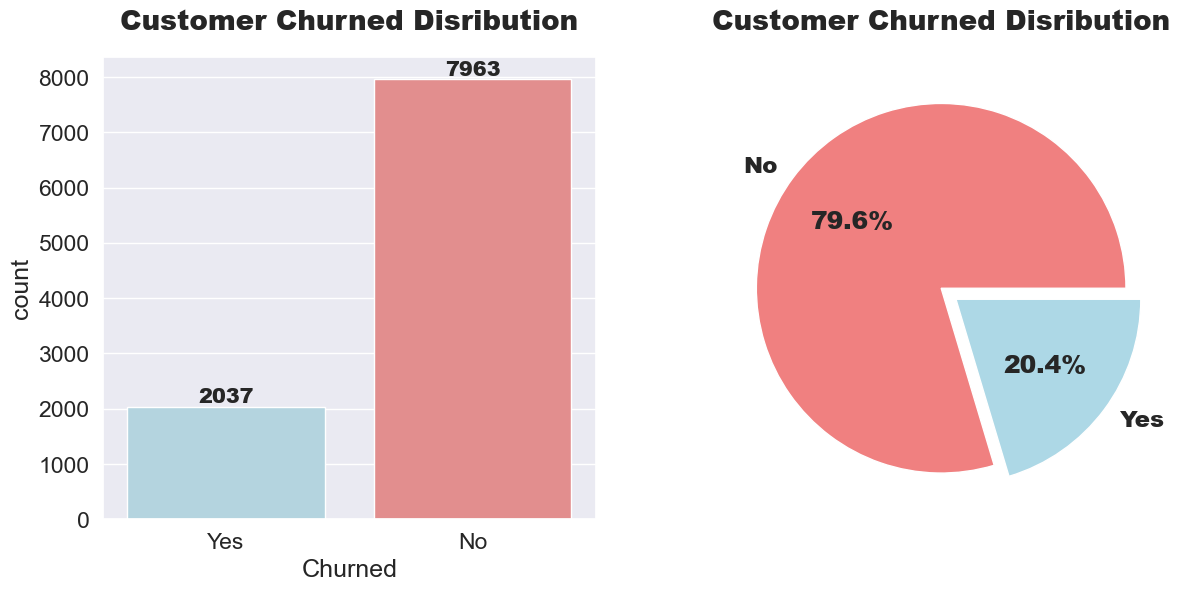

In [17]:
count = df["Churned"].value_counts()

custom_palette = {"No": "lightcoral", "Yes": "lightblue"}  # Swap colors

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
ax = sns.countplot(data=df, x="Churned", palette=custom_palette)
ax.bar_label(ax.containers[0],fontweight="black",size=15)
plt.title("Customer Churned Disribution",fontweight="black",size=20,pad=20)

plt.subplot(1,2,2)
plt.pie(count.values, labels=count.index, autopct="%1.1f%%",colors=[custom_palette[label] for label in count.index],
        textprops={"fontweight":"black"},explode=[0,0.1])
plt.title("Customer Churned Disribution",fontweight="black",size=20,pad=20)
plt.show()

In [18]:
''' There is class imbalance, to overcome -> SMOTE'''

' There is class imbalance, to overcome -> SMOTE'

In [19]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)

In [20]:
def countplot(column):
    df[column] = df[column].astype(str)

    custom_palette = {"No": "lightcoral", "Yes": "lightblue"}
    plt.figure(figsize=(12,4))
    ax = sns.countplot(x=column, data=df, hue="Churned",palette=custom_palette)
    for value in ax.patches:
        percentage = "{:.1f}%".format(100*value.get_height()/len(df[column]))
        x = value.get_x() + value.get_width() / 2 - 0.05
        y = value.get_y() + value.get_height()
        ax.annotate(percentage, (x,y), fontweight="black",size=15)
        
    plt.title(f"Customer Churned by {column}",fontweight="black",size=20,pad=20)
    plt.show()

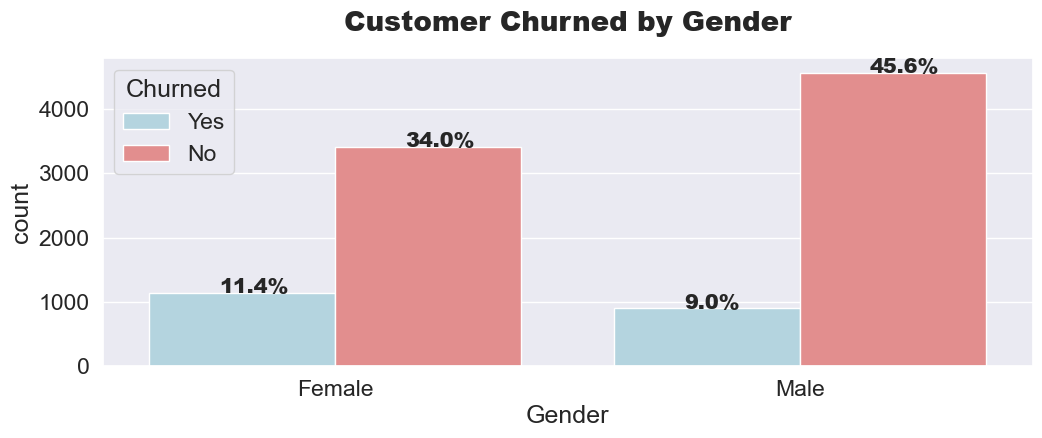

In [21]:
#2. Visualizing Customer Churned by Gender
countplot("Gender")

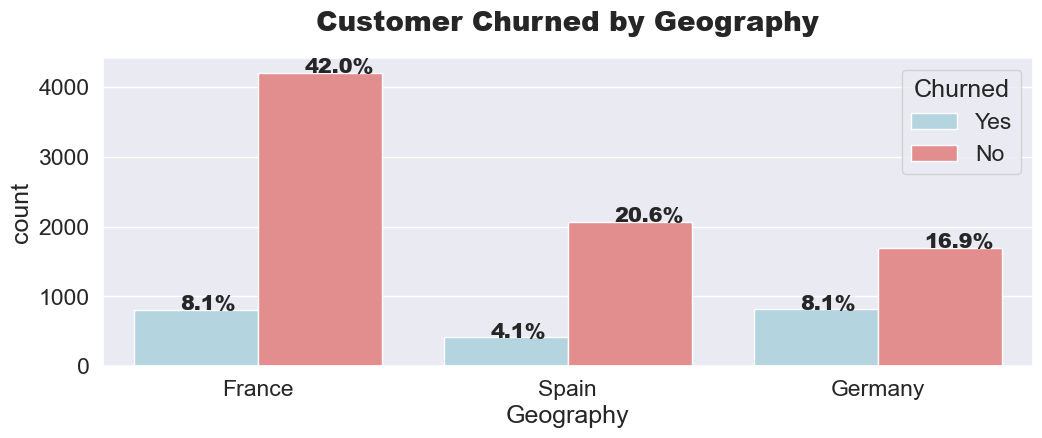

In [22]:
#3. Visualizing Customer Churned by Geoprahical Region
countplot("Geography")

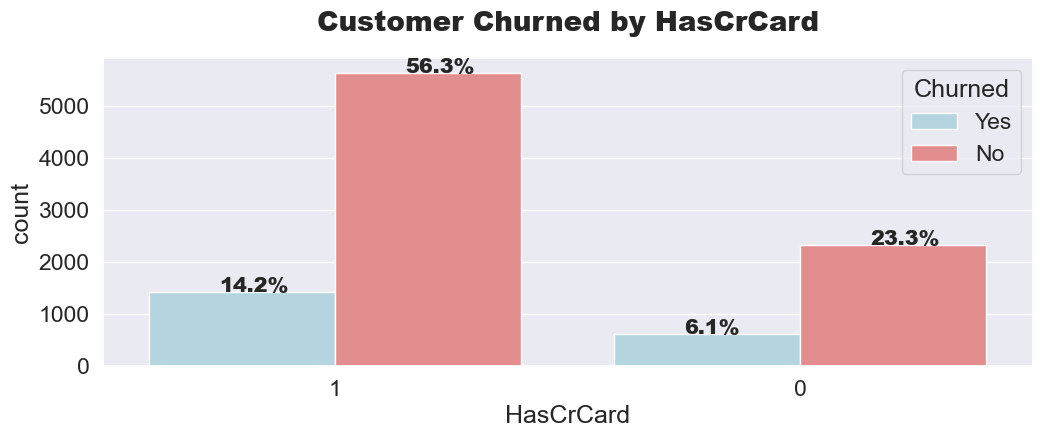

In [23]:
#4. Visualizing Customer Churn by "HasCrCard"
countplot("HasCrCard")

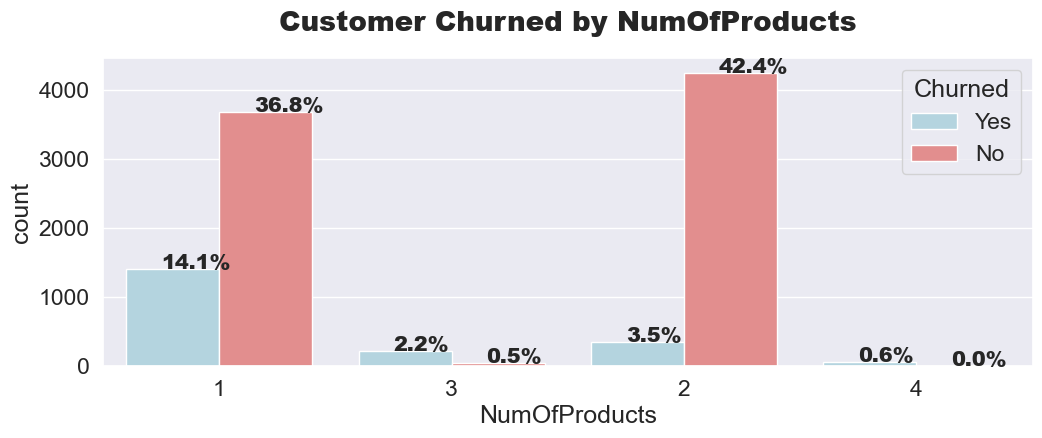

In [24]:
#5. Visualizing Customer Churned by "NumOfProducts".
countplot("NumOfProducts")

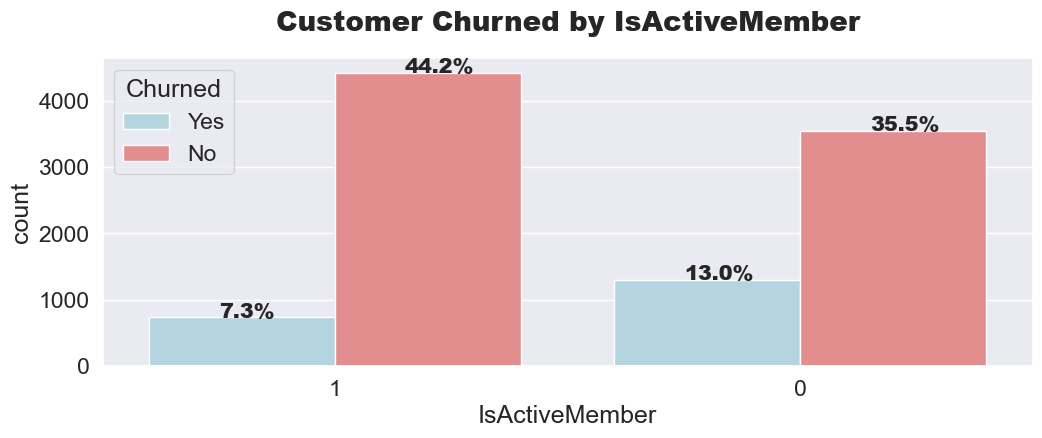

In [25]:
#6. Visualizing Customer Churned by "IsActiveMember".
countplot("IsActiveMember")

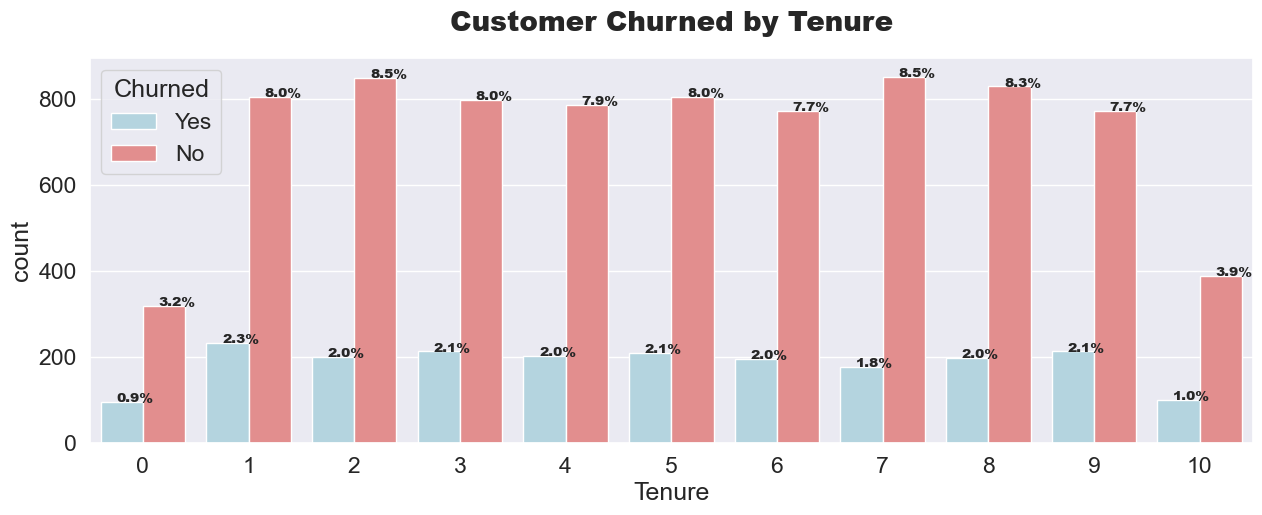

In [26]:
#7. Visualizing Customer Churned by "Tenure".
custom_palette = {"No": "lightcoral", "Yes": "lightblue"}

plt.figure(figsize=(15,5))
ax = sns.countplot(x="Tenure", data = df, hue="Churned", palette=custom_palette)
for value in ax.patches:
    percentage = "{:.1f}%".format(100*value.get_height()/len(df["Tenure"]))
    x = value.get_x() + value.get_width() / 2 - 0.05
    y = value.get_y() + value.get_height()
    ax.annotate(percentage, (x,y), fontweight="black",size=10)

plt.title("Customer Churned by Tenure",fontweight="black",size=20,pad=20)
plt.show()

In [27]:
def continous_plot(column):
    custom_palette = {"No": "lightcoral", "Yes": "lightblue"}
    
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    sns.histplot(x=column,hue="Churned",data=df,kde=True,palette=custom_palette)
    plt.title(f"Distribution of {column} by Churn Status",fontweight="black",pad=20,size=15)

    plt.subplot(1,2,2)
    sns.boxplot(x=df["Churned"],y=df[column],palette=custom_palette)
    plt.title(f"Distribution of {column} by Churn Status",fontweight="black",pad=20,size=15)
    plt.tight_layout()
    plt.show()

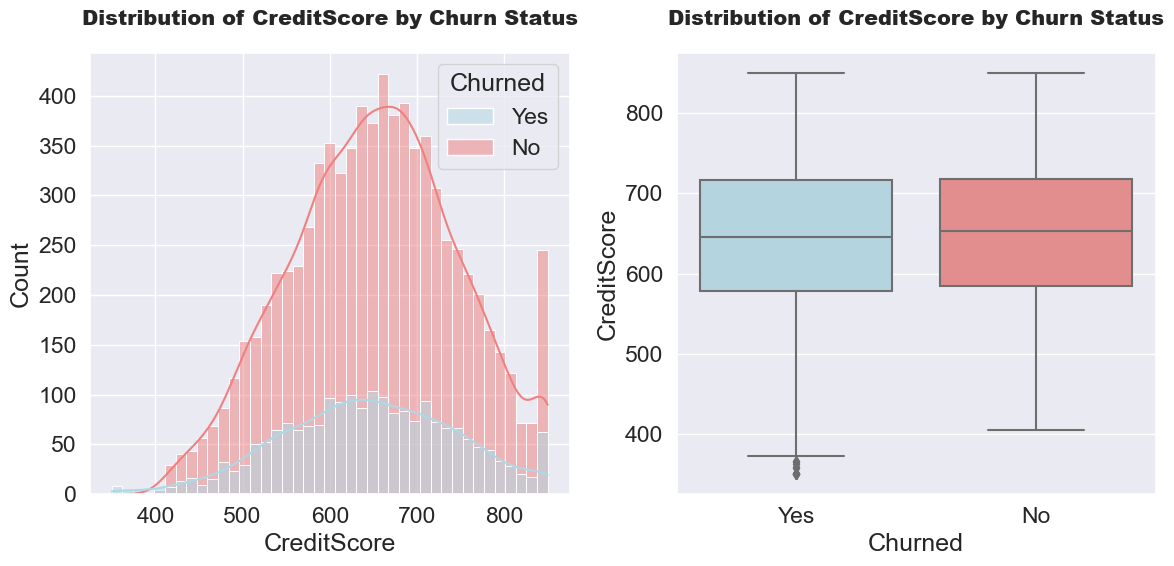

In [28]:
#8. Visualizing Customer Churned by "CreditScore".¶
continous_plot("CreditScore")

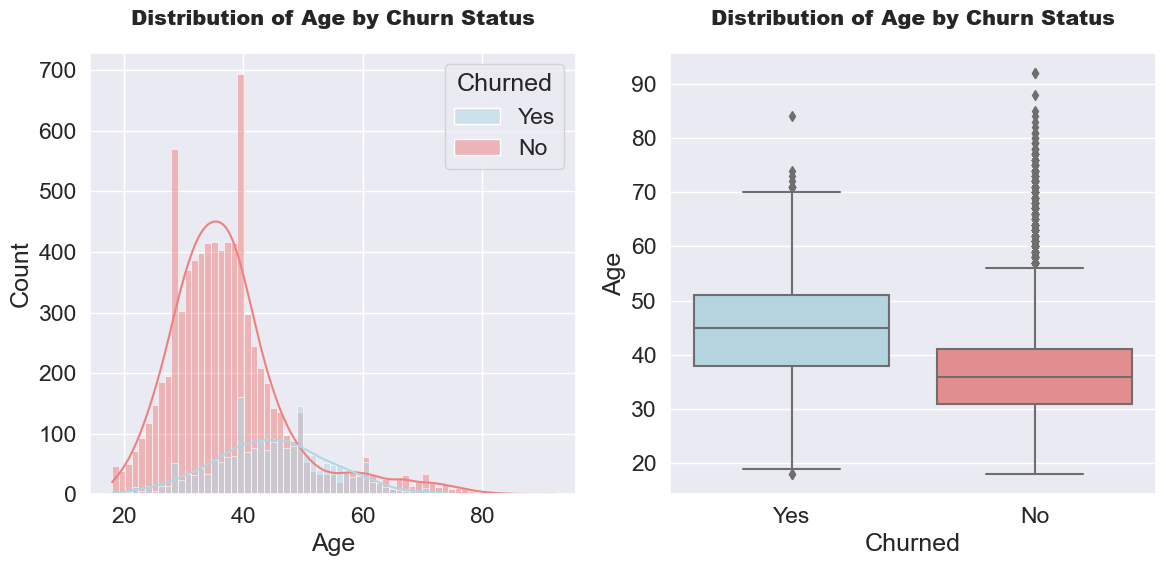

In [29]:
#9. Visualizing Customer Churned by "Age".
continous_plot("Age")

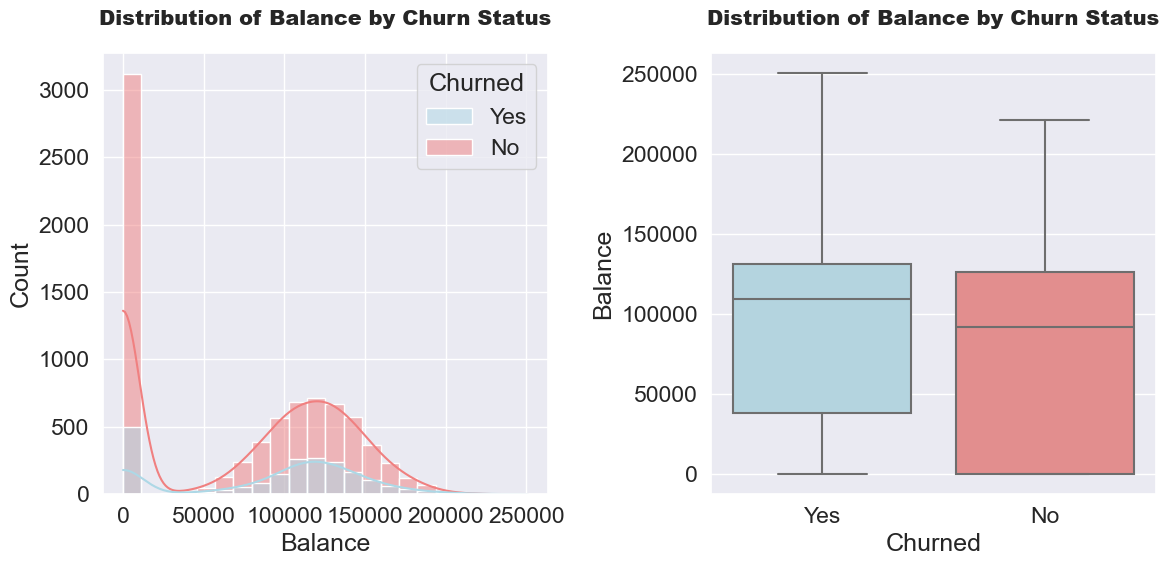

In [30]:
#10. Visualizing Customer Churned by "Balance."
continous_plot("Balance")

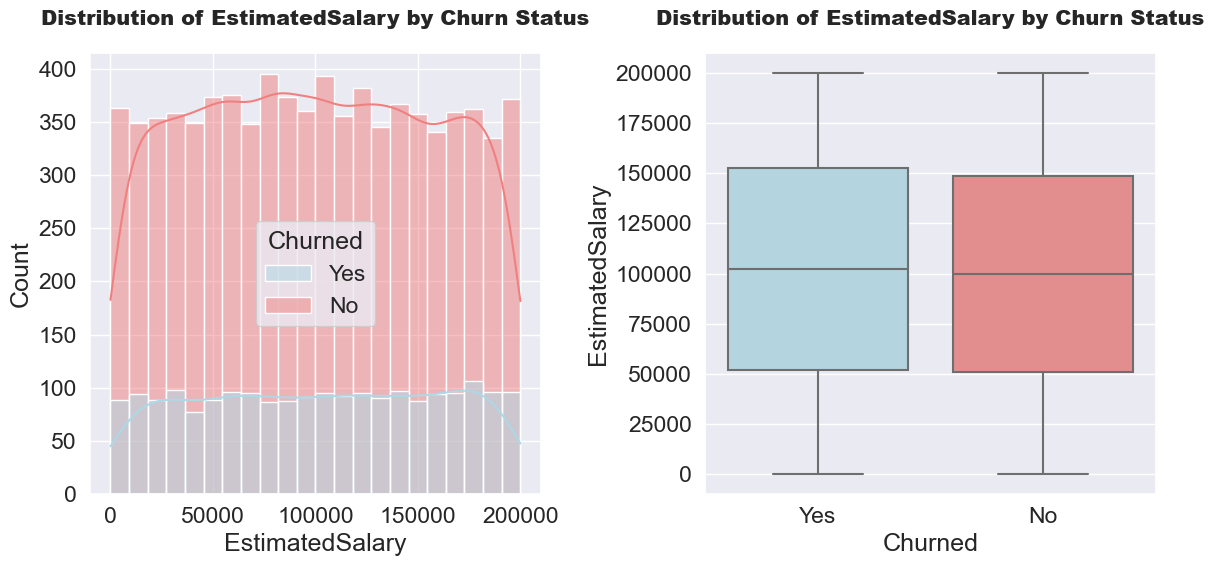

In [31]:
#11. Visualizing Customer Churned by "Estimated Salary".
continous_plot("EstimatedSalary")

## Feature Engineering

In [32]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,Yes
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,No
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,Yes
3,699,France,Female,39,1,0.00,2,0,0,93826.63,No
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,No


In [33]:
#1. Creating New Feature From "NumOfProducts" Feature
df["NumOfProducts"] = pd.to_numeric(df["NumOfProducts"])

conditions = [
    (df["NumOfProducts"] == 1),
    (df["NumOfProducts"] == 2), 
    (df["NumOfProducts"] > 2)
]
values = ["One Product", "Two Products", "More Than Two Products"]

In [34]:
df["Total_Products"] = np.select(conditions, values)

In [35]:
df.drop(columns="NumOfProducts", inplace=True)

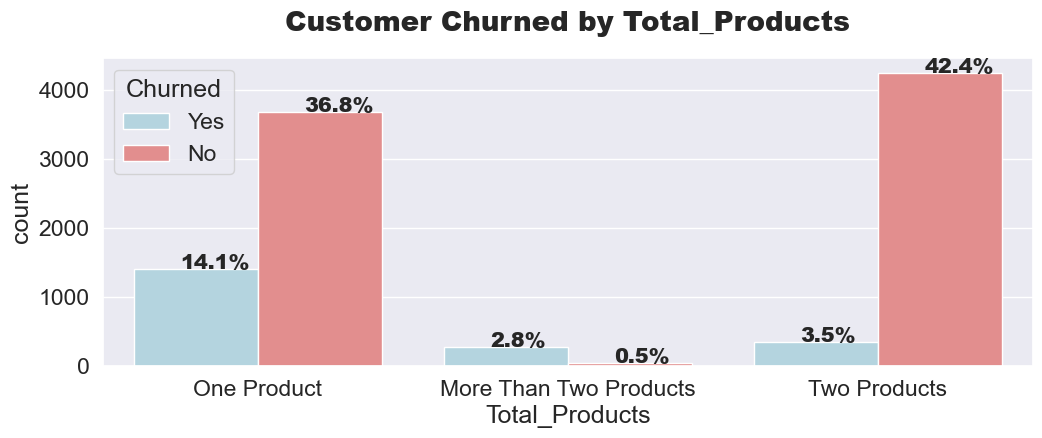

In [36]:
countplot("Total_Products")

In [37]:
#2. Creating New Feature From "Balance" Feature
conditions = [(df["Balance"]==0),(df["Balance"]>0)]
values = ["Zero Balance","More Than zero Balance"]

In [38]:
df["Account_Balance"] = np.select(conditions,values)

In [39]:
df.drop(columns="Balance", inplace=True)

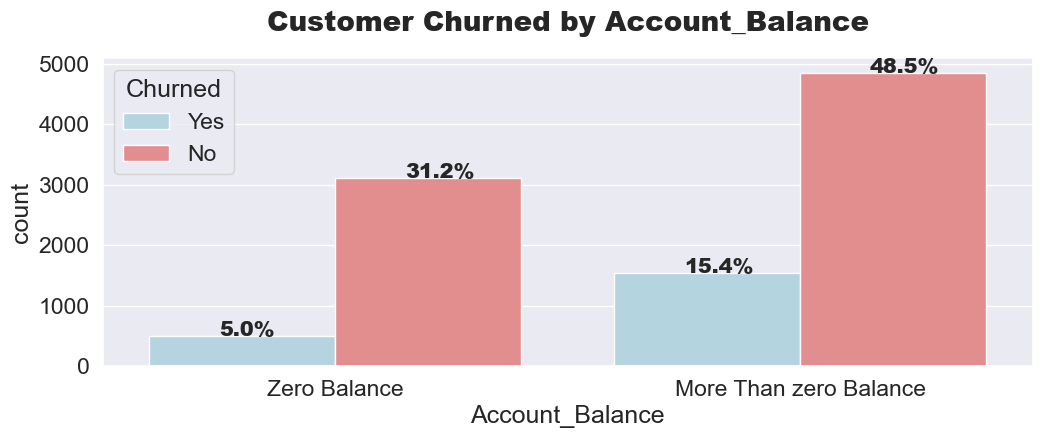

In [40]:
countplot("Account_Balance")

## Data Preprocessing

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   HasCrCard        10000 non-null  object 
 6   IsActiveMember   10000 non-null  object 
 7   EstimatedSalary  10000 non-null  float64
 8   Churned          10000 non-null  object 
 9   Total_Products   10000 non-null  object 
 10  Account_Balance  10000 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 859.5+ KB


In [42]:
#1. Computing Unique Values of Categorical Columns
cat_cols = ["Geography", "Gender","Total_Products", "Account_Balance"]

for col in cat_cols:
    print(f"Uniques Values in {col} column is", df[col].unique())
    print("-"*100,"\n")

Uniques Values in Geography column is ['France' 'Spain' 'Germany']
---------------------------------------------------------------------------------------------------- 

Uniques Values in Gender column is ['Female' 'Male']
---------------------------------------------------------------------------------------------------- 

Uniques Values in Total_Products column is ['One Product' 'More Than Two Products' 'Two Products']
---------------------------------------------------------------------------------------------------- 

Uniques Values in Account_Balance column is ['Zero Balance' 'More Than zero Balance']
---------------------------------------------------------------------------------------------------- 



In [43]:
#2. Performing One Hot Encoding on Categorical Features
df = pd.get_dummies(columns=cat_cols, data=df, drop_first=True, dtype=int)

In [44]:
#3. Encoding Target Variable
df["Churned"].replace({"No":0,"Yes":1},inplace=True)

In [45]:
df.head()

,CreditScore,Age,Tenure,HasCrCard,IsActiveMember,EstimatedSalary,Churned,Geography_Germany,Geography_Spain,Gender_Male,Total_Products_One Product,Total_Products_Two Products,Account_Balance_Zero Balance
0,619,42,2,1,1,101348.88,1,0,0,0,1,0,1
1,608,41,1,0,1,112542.58,0,0,1,0,1,0,0
2,502,42,8,1,0,113931.57,1,0,0,0,0,0,0
3,699,39,1,0,0,93826.63,0,0,0,0,0,1,1
4,850,43,2,1,1,79084.10,0,0,1,0,1,0,0


In [46]:
#4. Checking Skewness of Continous Features
cols = ["CreditScore", "Age", "EstimatedSalary"]

In [47]:
df[cols].skew().to_frame().rename(columns = {0:"Feature Skewness"})

,Feature Skewness
CreditScore,-0.071607
Age,1.011320
EstimatedSalary,0.002085


In [48]:
#4. Performing Log Transformation on Age Column
old_age = df["Age"]

In [49]:
df["Age"] = np.log(df["Age"])

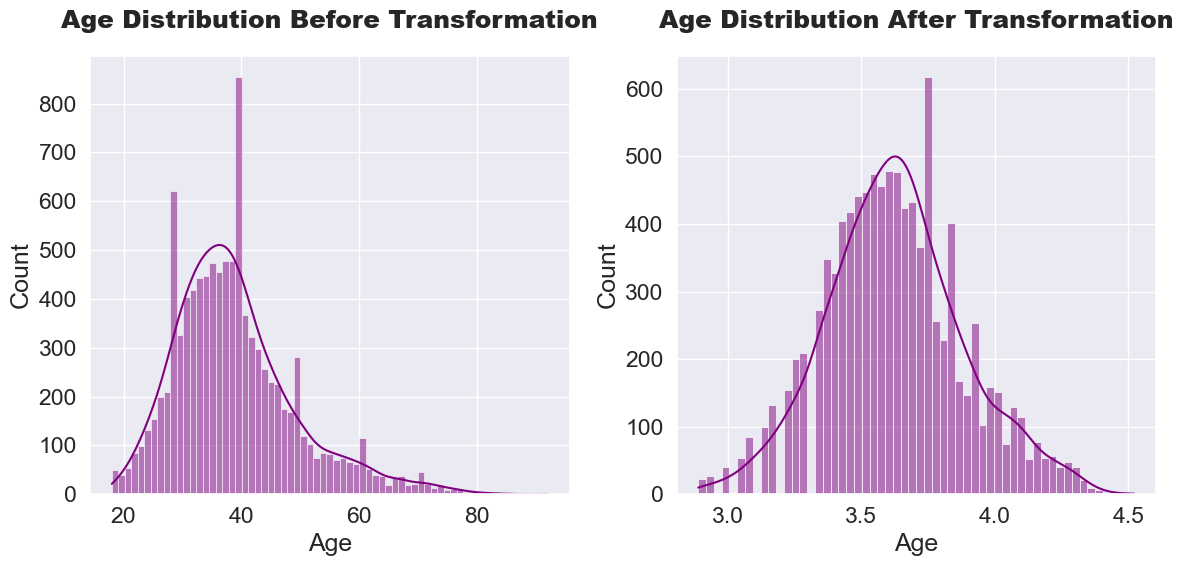

In [50]:
#5. Visualizing Age Before and After Transformation.
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.histplot(old_age, color="purple", kde=True)
plt.title("Age Distribution Before Transformation",fontweight="black",size=18,pad=20)

plt.subplot(1,2,2)
sns.histplot(df["Age"], color="purple", kde=True)
plt.title("Age Distribution After Transformation",fontweight="black",size=18,pad=20)
plt.tight_layout()
plt.show()

In [51]:
df = df.apply(pd.to_numeric, errors='ignore')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   CreditScore                   10000 non-null  int64  
 1   Age                           10000 non-null  float64
 2   Tenure                        10000 non-null  int64  
 3   HasCrCard                     10000 non-null  int64  
 4   IsActiveMember                10000 non-null  int64  
 5   EstimatedSalary               10000 non-null  float64
 6   Churned                       10000 non-null  int64  
 7   Geography_Germany             10000 non-null  int32  
 8   Geography_Spain               10000 non-null  int32  
 9   Gender_Male                   10000 non-null  int32  
 10  Total_Products_One Product    10000 non-null  int32  
 11  Total_Products_Two Products   10000 non-null  int32  
 12  Account_Balance_Zero Balance  10000 non-null  int32  
dtypes:

In [52]:
df = df.astype(np.int64)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   CreditScore                   10000 non-null  int64
 1   Age                           10000 non-null  int64
 2   Tenure                        10000 non-null  int64
 3   HasCrCard                     10000 non-null  int64
 4   IsActiveMember                10000 non-null  int64
 5   EstimatedSalary               10000 non-null  int64
 6   Churned                       10000 non-null  int64
 7   Geography_Germany             10000 non-null  int64
 8   Geography_Spain               10000 non-null  int64
 9   Gender_Male                   10000 non-null  int64
 10  Total_Products_One Product    10000 non-null  int64
 11  Total_Products_Two Products   10000 non-null  int64
 12  Account_Balance_Zero Balance  10000 non-null  int64
dtypes: int64(13)
memory usage: 1015.

In [54]:
#6. Segregating Features & Labels for Model Training
X = df.drop(columns=["Churned"])
y = df["Churned"]

In [55]:
#7. Splitting Data For Model Training & Testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
print("X_train shape is: ", X_train.shape)
print("X_test shape is: ",X_test.shape)
print("y_train shape is:",y_train.shape)
print("y_test shape is: ",y_test.shape)

X_train shape is:  (8000, 12)
X_test shape is:  (2000, 12)
y_train shape is: (8000,)
y_test shape is:  (2000,)


In [57]:
#8. Applying SMOTE to Overcome the Class-Imbalance in Target Variable
smt = SMOTE(random_state=42)
X_train_resampled,y_train_resampled = smt.fit_resample(X_train,y_train)
print(X_train_resampled.shape ,y_train_resampled.shape)

(12712, 12) (12712,)


In [58]:
y_train_resampled.value_counts().to_frame()

,count
Churned,
0,6356
1,6356


## Model Creation using DecisionTree

In [59]:
model_dt = DecisionTreeClassifier()

In [60]:
param_grid={"max_depth":[3,4,5,6,7,8,9,10],
              "min_samples_split":[2,3,4,5,6,7,8],
              "min_samples_leaf":[1,2,3,4,5,6,7,8],
              "criterion":["gini","entropy"],
              "splitter":["best","random"],
              "max_features":["auto",None],
              "random_state":[0,42]}

In [61]:
grid_search = GridSearchCV(model_dt, param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train_resampled, y_train_resampled)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
                         'max_features': ['auto', None],
                         'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8],
                         'min_samples_split': [2, 3, 4, 5, 6, 7, 8],
                         'random_state': [0, 42],
                         'splitter': ['best', 'random']})

In [62]:
#2. Fetching the Best Parameters for DecisionTree Model.
best_parameters = grid_search.best_params_
best_parameters

{'criterion': 'entropy',
 'max_depth': 8,
 'max_features': None,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'random_state': 0,
 'splitter': 'random'}

In [63]:
#3. Creating DecisionTree Model Using Best Parameters
model_dt = DecisionTreeClassifier(**best_parameters)
model_dt.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(criterion='entropy', max_depth=8, min_samples_leaf=2,
                       random_state=0, splitter='random')

In [64]:
#4. Computing Model Accuracy.
y_train_pred = model_dt.predict(X_train_resampled)
y_test_pred = model_dt.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.88      0.85      0.87      1607
           1       0.47      0.53      0.50       393

    accuracy                           0.79      2000
   macro avg       0.68      0.69      0.68      2000
weighted avg       0.80      0.79      0.80      2000



In [65]:
ac_model = round(accuracy_score(y_train_resampled, y_train_pred) * 100,2)
ac_test = round(accuracy_score(y_test,y_test_pred)*100,2)

print(f"Accuracy of Model on Training Data: {ac_model}%")
print(f"Accuracy of Model on Testing Data: {ac_test}%")

Accuracy of Model on Training Data: 83.2%
Accuracy of Model on Testing Data: 79.15%


In [66]:
#6. Finding Importance of Features in DecisionTreeClassifier
imp_df = pd.DataFrame({
    "Feature_Name": X_train.columns,
    "Importance": model_dt.feature_importances_})

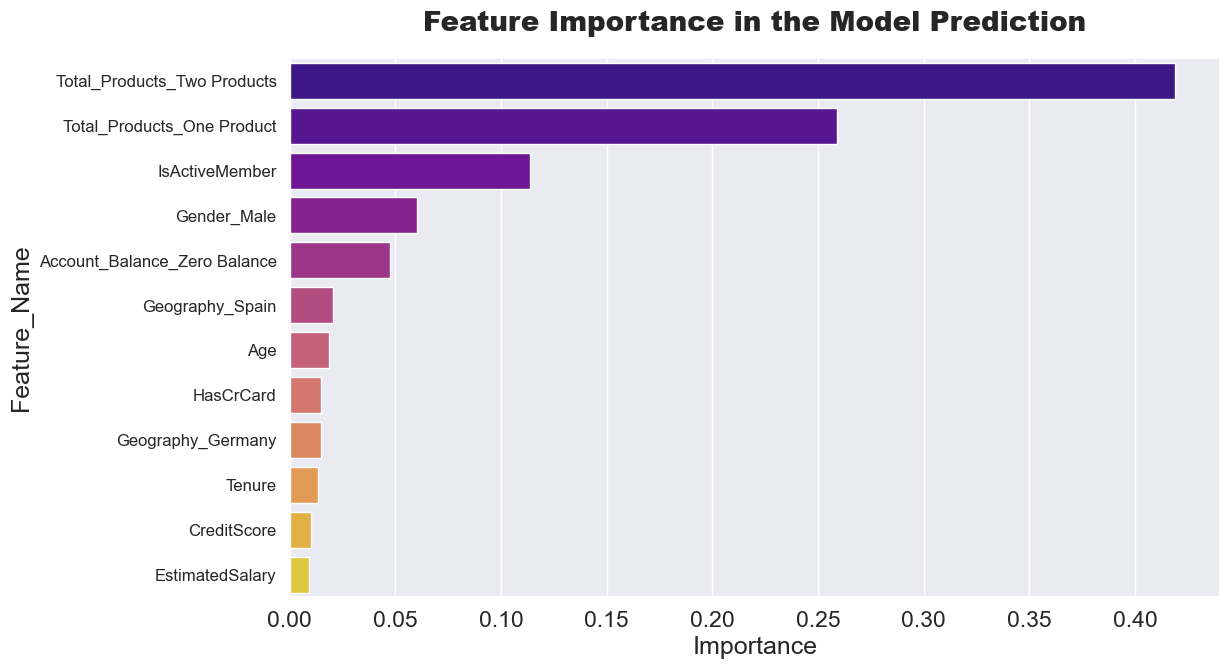

In [67]:
features = imp_df.sort_values(by="Importance",ascending=False)

plt.figure(figsize=(12,7))
sns.barplot(x="Importance", y="Feature_Name", data=features, palette="plasma")
plt.title("Feature Importance in the Model Prediction", fontweight="black", size=20, pad=20)
plt.yticks(size=12)
plt.show()

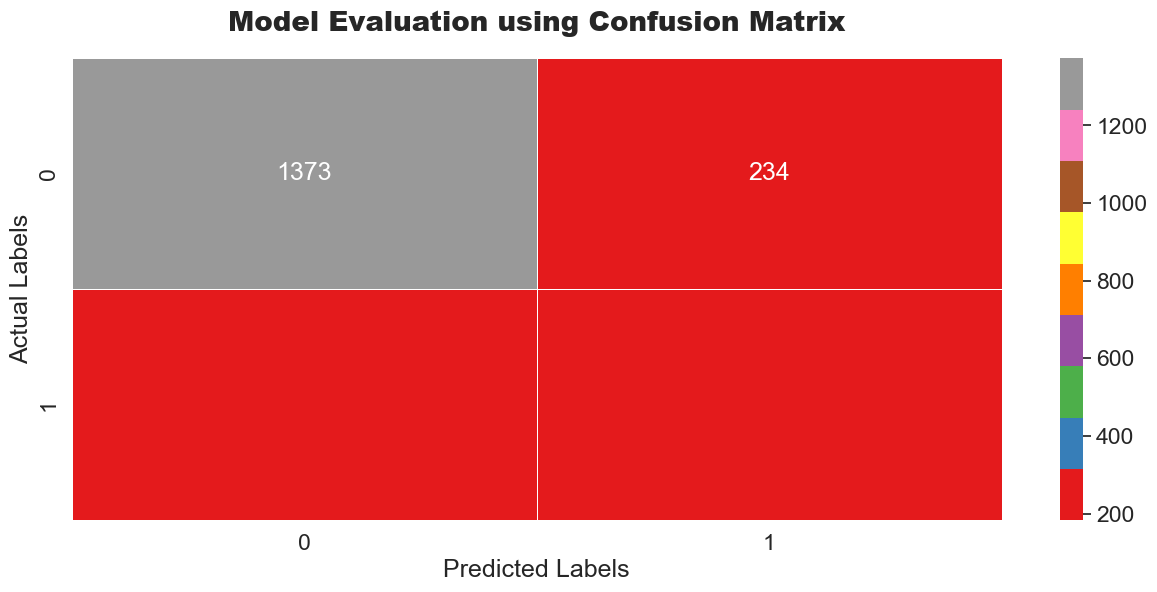

In [68]:
#8. Model Evaluation using Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(15,6))
sns.heatmap(data=cm, linewidth=.5, annot=True, fmt="g", cmap="Set1")
plt.title("Model Evaluation using Confusion Matrix",fontsize=20,pad=20,fontweight="black")
plt.ylabel("Actual Labels")
plt.xlabel("Predicted Labels")
plt.show()

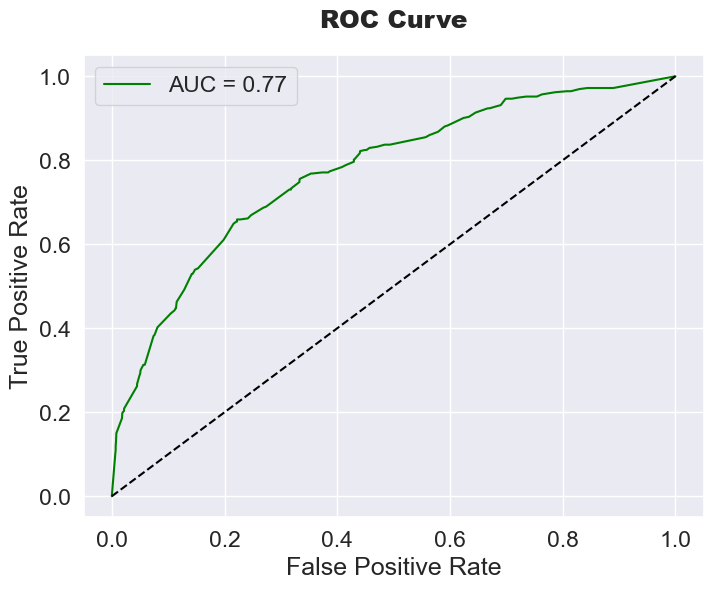

In [69]:
#9. Model Evaluation: ROC Curve and Area Under the Curve (AUC)¶
y_pred_proba = model_dt.predict_proba(X_test)[:][:,1]

df_actual_predicted = pd.concat([pd.DataFrame(np.array(y_test), columns=["y_actual"])])
df_actual_predicted.index = y_test.index


fpr, tpr, thresholds = roc_curve(df_actual_predicted["y_actual"], y_pred_proba)
auc = roc_auc_score(df_actual_predicted["y_actual"], y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}",color="green")
plt.plot([0, 1], [0, 1], linestyle="--", color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve",pad=20,fontweight="black")
plt.legend()
plt.show()

## Model Creation using RandomForest

In [71]:
#1. Performing Grid-Search with cross-validation to find the best Parameters for the Model
rfc = RandomForestClassifier()

param_grid = {
    "max_depth":[3,4,5,6,7,8],
              "min_samples_split":[3,4,5,6,7,8],
              "min_samples_leaf":[3,4,5,6,7,8],
              "n_estimators": [50,70,90,100],
              "criterion":["gini","entropy"]}

grid_search = GridSearchCV(rfc, param_grid, cv = 5, n_jobs=-1)
grid_search.fit(X_train_resampled, y_train_resampled)

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8],
                         'min_samples_leaf': [3, 4, 5, 6, 7, 8],
                         'min_samples_split': [3, 4, 5, 6, 7, 8],
                         'n_estimators': [50, 70, 90, 100]})

In [74]:
#2. Fetching the Best Parameters for RandomForest Model.
best_parameters  = grid_search.best_params_
best_parameters

{'criterion': 'entropy',
 'max_depth': 8,
 'min_samples_leaf': 6,
 'min_samples_split': 8,
 'n_estimators': 100}

In [76]:
#3. Creating RandomForest Model Using Best Parameters.
rfc = RandomForestClassifier(**best_parameters)
rfc.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(criterion='entropy', max_depth=8, min_samples_leaf=6,
                       min_samples_split=8)

In [77]:
#4. Computing Model Accuracy.
y_test_pred = rfc.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1607
           1       0.44      0.53      0.49       393

    accuracy                           0.78      2000
   macro avg       0.66      0.69      0.67      2000
weighted avg       0.79      0.78      0.78      2000



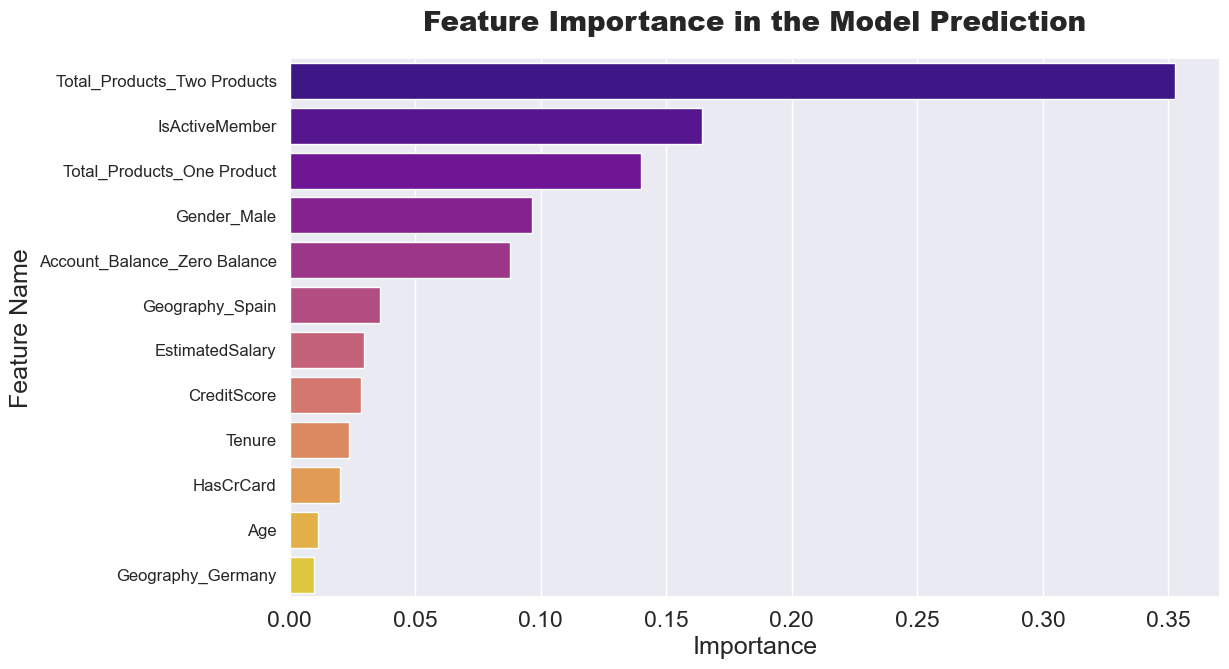

In [80]:
#6. Finding Importance of Features in RandomForest Model
imp_df = pd.DataFrame({
    "Feature Name":X_train.columns,
    "Importance":rfc.feature_importances_
})

features = imp_df.sort_values(by="Importance",ascending=False)

plt.figure(figsize=(12,7))
sns.barplot(x="Importance", y="Feature Name", data=features, palette="plasma")
plt.title("Feature Importance in the Model Prediction", fontweight="black", size=20, pad=20)
plt.yticks(size=12)
plt.show()

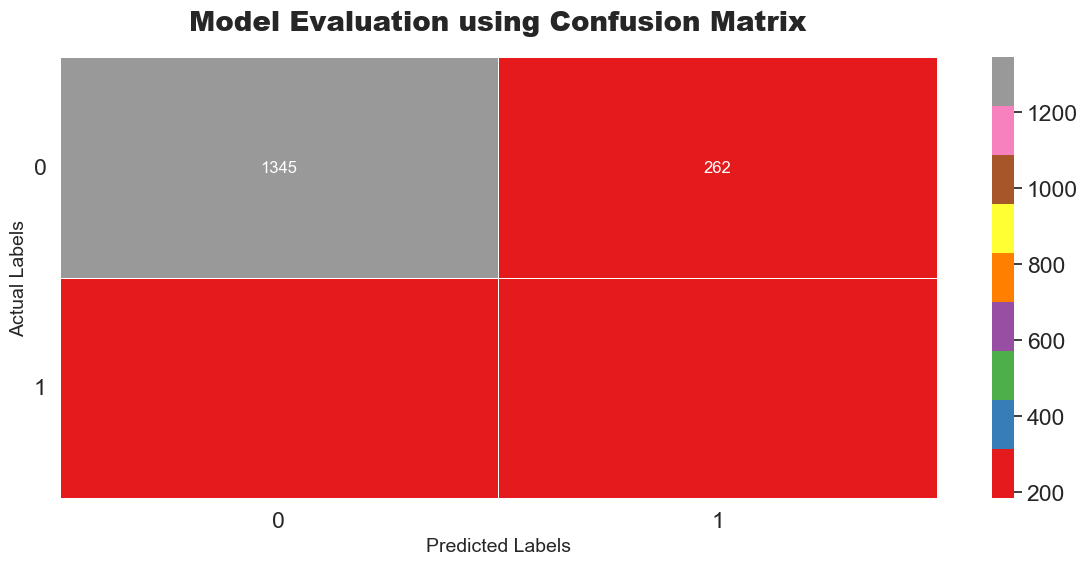

In [97]:
cm = confusion_matrix(y_test,y_test_pred)

plt.figure(figsize=(12,6))
sns.heatmap(data=cm, linewidth=.5, annot=True, fmt="g", cmap="Set1",
            annot_kws={"size": 12}) 
plt.title("Model Evaluation using Confusion Matrix", fontsize=20, pad=20, fontweight="black")
plt.ylabel("Actual Labels", fontsize=14)
plt.xlabel("Predicted Labels", fontsize=14)
plt.yticks(rotation=0)  
plt.tight_layout()
plt.show()

In [100]:
cm

array([[1345,  262],
       [ 183,  210]], dtype=int64)

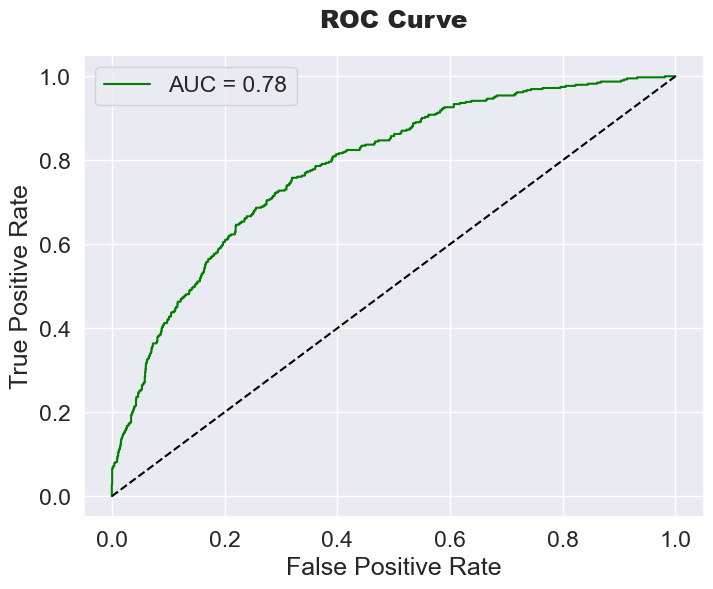

In [85]:
#9. Model Evaluation: ROC Curve and Area Under the Curve (AUC)
y_pred_proba = rfc.predict_proba(X_test)[:][:,1]

df_actual_predicted = pd.concat([pd.DataFrame(np.array(y_test), columns=["y_actual"])])
df_actual_predicted.index = y_test.index


fpr, tpr, thresholds = roc_curve(df_actual_predicted["y_actual"], y_pred_proba)
auc = roc_auc_score(df_actual_predicted["y_actual"], y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}",color="green")
plt.plot([0, 1], [0, 1], linestyle="--", color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve",pad=20,fontweight="black")
plt.legend()
plt.show()